Weights (W1, W2): [[ 4.10519231 -5.72442044]]
Bias (b): [4.49531259]
Source Domain (ID) Accuracy:   0.95
Target Domain (OOD) Accuracy:  0.71


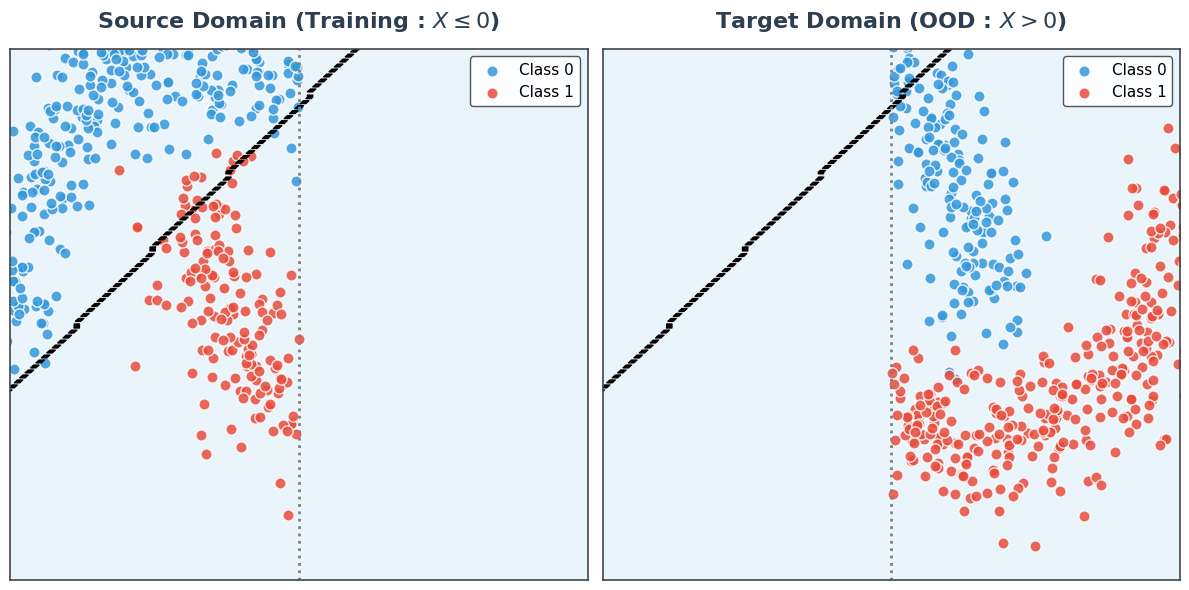

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ==========================================
# 1. Base Data Generation (Two Moons)
# ==========================================
X_base, y_base = make_moons(n_samples=1000, noise=0.15, random_state=42)

# Shift X so the center of the dataset is exactly at X = 0 
X_base[:, 0] = X_base[:, 0] - 0.5 

# ==========================================
# 2. Split into Source (ID) and Target (OOD)
# ==========================================
# Source Domain: Left side (X <= 0)
source_mask = X_base[:, 0] <= 0
X_source, y_source = X_base[source_mask], y_base[source_mask]

# Target Domain: Right side (X > 0)
target_mask = X_base[:, 0] > 0
X_target, y_target = X_base[target_mask], y_base[target_mask]

# ==========================================
# 3. Test Logistic Regression Performance
# ==========================================
clf = LogisticRegression()
clf.fit(X_source, y_source)


print("Weights (W1, W2):", clf.coef_)
print("Bias (b):", clf.intercept_)


acc_source = accuracy_score(y_source, clf.predict(X_source))
acc_target = accuracy_score(y_target, clf.predict(X_target))

print(f"Source Domain (ID) Accuracy:   {acc_source:.2f}")
print(f"Target Domain (OOD) Accuracy:  {acc_target:.2f}")

# ==========================================
# 4. Visualization
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

color_blue = '#3498db'
color_red = '#e74c3c'

# Decision Boundary plotting function
def plot_boundary(ax, X, model):
    x_min, x_max = -1.5, 1.5
    y_min, y_max = -1.0, 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.1, colors=[color_blue, color_red])
    ax.contour(xx, yy, Z, colors='k', linewidths=1, linestyles='--')

# --- Plot Source Domain (S) ---
plot_boundary(ax1, X_source, clf)
ax1.scatter(X_source[y_source == 0][:, 0], X_source[y_source == 0][:, 1], c=color_blue, alpha=0.85, edgecolors='white', s=65, label='Class 0')
ax1.scatter(X_source[y_source == 1][:, 0], X_source[y_source == 1][:, 1], c=color_red, alpha=0.85, edgecolors='white', s=65, label='Class 1')
ax1.set_title(f"Source Domain (Training : $X \leq 0$)", fontsize=16, fontweight='600', color='#2c3e50', pad=15)
ax1.axvline(x=0, color='gray', linestyle=':', linewidth=2) # Add the X=0 split line

# --- Plot Target Domain (T) ---
plot_boundary(ax2, X_target, clf)
ax2.scatter(X_target[y_target == 0][:, 0], X_target[y_target == 0][:, 1], c=color_blue, alpha=0.85, edgecolors='white', s=65, label='Class 0')
ax2.scatter(X_target[y_target == 1][:, 0], X_target[y_target == 1][:, 1], c=color_red, alpha=0.85, edgecolors='white', s=65, label='Class 1')
ax2.set_title(f"Target Domain (OOD : $X > 0$)", fontsize=16, fontweight='600', color='#2c3e50', pad=15)
ax2.axvline(x=0, color='gray', linestyle=':', linewidth=2) # Add the X=0 split line

# --- Clean Aesthetic Formatting & Legends ---
for ax in [ax1, ax2]:
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.0, 1.0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#444444')
        spine.set_linewidth(1.2)
        
    ax.legend(loc='upper right', fontsize=11, frameon=True, edgecolor='#444444', facecolor='white', framealpha=0.9)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

After CORAL Alignment:
Target Domain Accuracy (CORAL): 0.80



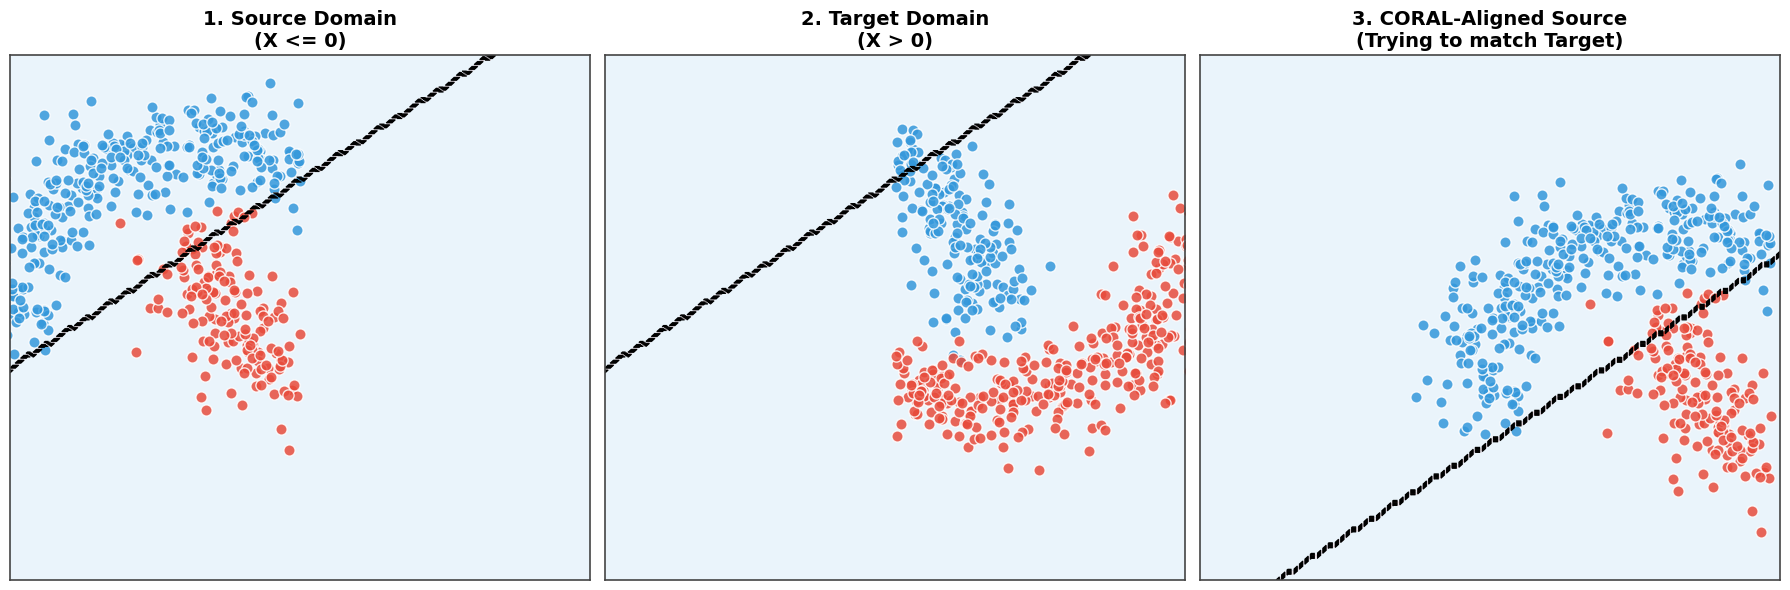

In [11]:
from scipy.linalg import fractional_matrix_power

# ==========================================
# 5. The CORAL Algorithm Implementation
# ==========================================
def coral_alignment(X_s, X_t, lambda_reg=1.0):
    d = X_s.shape[1]
    Cs = np.cov(X_s, rowvar=False) + np.eye(d) * lambda_reg
    Ct = np.cov(X_t, rowvar=False) + np.eye(d) * lambda_reg
    
    Cs_inv_sqrt = fractional_matrix_power(Cs, -0.5)
    Ct_sqrt = fractional_matrix_power(Ct, 0.5)
    
    X_s_centered = X_s - np.mean(X_s, axis=0)
    X_s_aligned = X_s_centered @ Cs_inv_sqrt @ Ct_sqrt + np.mean(X_t, axis=0)
    
    return np.real(X_s_aligned)

# Apply CORAL
X_source_coral = coral_alignment(X_source, X_target)

# ==========================================
# 6. Test Logistic Regression Performance (AFTER CORAL)
# ==========================================
clf_after = LogisticRegression()
clf_after.fit(X_source_coral, y_source)

acc_target_after = accuracy_score(y_target, clf_after.predict(X_target))

print("After CORAL Alignment:")
print(f"Target Domain Accuracy (CORAL): {acc_target_after:.2f}\n")

# ==========================================
# 7. Visualization
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Source Domain ---
plot_boundary(ax1, X_source, clf_before)
ax1.scatter(X_source[y_source == 0][:, 0], X_source[y_source == 0][:, 1], c=color_blue, alpha=0.85, edgecolors='white', s=65)
ax1.scatter(X_source[y_source == 1][:, 0], X_source[y_source == 1][:, 1], c=color_red, alpha=0.85, edgecolors='white', s=65)
ax1.set_title(f"1. Source Domain\n(X <= 0)", fontsize=14, fontweight='600')

# --- Plot 2: Target Domain ---
plot_boundary(ax2, X_target, clf_before)
ax2.scatter(X_target[y_target == 0][:, 0], X_target[y_target == 0][:, 1], c=color_blue, alpha=0.85, edgecolors='white', s=65)
ax2.scatter(X_target[y_target == 1][:, 0], X_target[y_target == 1][:, 1], c=color_red, alpha=0.85, edgecolors='white', s=65)
ax2.set_title(f"2. Target Domain\n(X > 0)", fontsize=14, fontweight='600')

# --- Plot 3: CORAL Aligned Source ---
plot_boundary(ax3, X_source_coral, clf_after)
ax3.scatter(X_source_coral[y_source == 0][:, 0], X_source_coral[y_source == 0][:, 1], c=color_blue, alpha=0.85, edgecolors='white', s=65)
ax3.scatter(X_source_coral[y_source == 1][:, 0], X_source_coral[y_source == 1][:, 1], c=color_red, alpha=0.85, edgecolors='white', s=65)
ax3.set_title(f"3. CORAL-Aligned Source\n(Trying to match Target)", fontsize=14, fontweight='600')

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('#444444'); spine.set_linewidth(1.2)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()